# L3 Photonic Crystal Cavity - MEEP Simulation

This notebook simulates an L3 cavity in a triangular lattice photonic crystal slab using MEEP (MIT Electromagnetic Equation Propagation).

## Overview

**L3 Cavity**: Three missing holes in a row in a 2D photonic crystal
- **Application**: High Purcell factor enhancement, quantum dot coupling
- **Expected Q-factor**: ~2,000-30,000 (with optimization)
- **Mode volume**: ~0.75(λ/n)³

## Physical Parameters
- Lattice constant: a = 240 nm
- Hole radius: r = 0.30a (72 nm)
- Modified end holes: r = 0.24a, shifted by 0.16a
- Material: Silicon (n = 3.46)

## 1. Setup and Imports

In [47]:
# Import required libraries
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"MEEP version: {mp.__version__ if hasattr(mp, '__version__') else 'Unknown'}")

✓ Libraries imported successfully
MEEP version: 1.31.0


## 2. Simulation Parameters

Adjust these parameters to control simulation accuracy and speed:

In [48]:
# ============================================================================
# ADJUSTABLE PARAMETERS
# ============================================================================

# Simulation mode
SIMULATION_2D = False  # True for 2D (faster), False for 3D (more accurate)

# Grid resolution (pixels per lattice constant)
# Higher = more accurate but slower
# Recommended: 20-30 for testing, 40+ for publication
RESOLUTION = 20

# Runtime after sources finish (in time units)
# Higher = better frequency resolution
RUNTIME = 200

# Physical parameters (normalized, a = 1)
a = 1.0                    # Lattice constant (normalized)
r = 0.30 * a              # Regular hole radius
r_modified = 0.24 * a     # Modified end hole radius
shift = 0.16 * a          # End hole shift distance
slab_thickness = 0.6 * a  # Slab thickness
n_si = 3.46               # Silicon refractive index

# Frequency parameters
fcen = 0.25    # Center frequency (a/λ)
df = 0.2       # Frequency width

print("="*70)
print("SIMULATION CONFIGURATION")
print("="*70)
print(f"Mode: {'2D' if SIMULATION_2D else '3D'}")
print(f"Resolution: {RESOLUTION} pixels/a")
print(f"Runtime: {RUNTIME} time units")
print(f"\nPhysical Parameters:")
print(f"  Hole radius: {r:.2f}a")
print(f"  Modified radius: {r_modified:.2f}a")
print(f"  Shift: {shift:.2f}a")
print(f"  Slab thickness: {slab_thickness:.1f}a")
print(f"  Silicon index: {n_si}")
print("="*70)

SIMULATION CONFIGURATION
Mode: 3D
Resolution: 20 pixels/a
Runtime: 200 time units

Physical Parameters:
  Hole radius: 0.30a
  Modified radius: 0.24a
  Shift: 0.16a
  Slab thickness: 0.6a
  Silicon index: 3.46


## 3. Define Computational Domain

In [49]:
# Define cell size based on 2D/3D mode
if SIMULATION_2D:
    sx = 15 * a
    sy = 12 * a
    cell_size = mp.Vector3(sx, sy, 0)
    dims = 2
else:
    sx = 15 * a
    sy = 12 * a
    sz = 6 * a
    cell_size = mp.Vector3(sx, sy, sz)
    dims = 3

print(f"Computational domain: {cell_size}")
print(f"Dimensions: {dims}D")

# PML boundary layers
pml_thickness = 1.0
pml_layers = [mp.PML(thickness=pml_thickness)]

print(f"PML thickness: {pml_thickness}a")

Computational domain: Vector3<15.0, 12.0, 6.0>
Dimensions: 3D
PML thickness: 1.0a


## 4. Create Geometry - Triangular Lattice with L3 Cavity

The L3 cavity is formed by removing 3 holes in a row. End holes are shifted outward and have reduced radius for Q-factor optimization.

In [50]:
def create_l3_geometry(dims):
    """
    Create L3 cavity geometry in triangular lattice
    
    Returns:
        geometry: List of MEEP geometry objects
        hole_count: Number of holes created
    """
    geometry = []
    si = mp.Medium(index=n_si)
    
    # Create silicon slab (3D only)
    if dims == 3:
        slab = mp.Block(
            size=mp.Vector3(sx, sy, slab_thickness),
            center=mp.Vector3(0, 0, 0),
            material=si
        )
        geometry.append(slab)
        default_material = mp.air
    else:
        default_material = si
    
    # Create triangular lattice of holes
    nx_range = 8
    ny_range = 7
    
    # Define cavity (3 missing holes)
    cavity_positions = {(0, 0), (1, 0), (-1, 0)}
    
    # Define modified holes at ends
    modified_positions = {(2, 0), (-2, 0)}
    
    hole_count = 0
    
    for i in range(-nx_range, nx_range + 1):
        for j in range(-ny_range, ny_range + 1):
            # Triangular lattice position
            x_pos = i * a
            y_pos = j * a * np.sqrt(3)
            
            # Shift every other row
            if j % 2 == 1:
                x_pos += 0.5 * a
            
            # Skip cavity holes
            if (i, j) in cavity_positions:
                continue
            
            # Apply modifications to end holes
            if (i, j) in modified_positions:
                x_pos += np.sign(i) * shift
                hole_radius = r_modified
            else:
                hole_radius = r
            
            # Create air hole
            if dims == 3:
                hole = mp.Cylinder(
                    radius=hole_radius,
                    height=slab_thickness + 0.2,
                    center=mp.Vector3(x_pos, y_pos, 0),
                    material=mp.air
                )
            else:  # 2D
                hole = mp.Cylinder(
                    radius=hole_radius,
                    center=mp.Vector3(x_pos, y_pos, 0),
                    material=mp.air
                )
            
            geometry.append(hole)
            hole_count += 1
    
    return geometry, default_material, hole_count

# Create geometry
geometry, default_material, hole_count = create_l3_geometry(dims)

print(f"\n✓ Geometry created:")
print(f"  Total holes: {hole_count}")
print(f"  Cavity type: L3 (3 missing holes)")
print(f"  Modified holes: 2 (at ends)")
print(f"  Lattice: Triangular")


✓ Geometry created:
  Total holes: 252
  Cavity type: L3 (3 missing holes)
  Modified holes: 2 (at ends)
  Lattice: Triangular


## 5. Visualize Cavity Structure

Before running the simulation, let's visualize the cavity geometry:

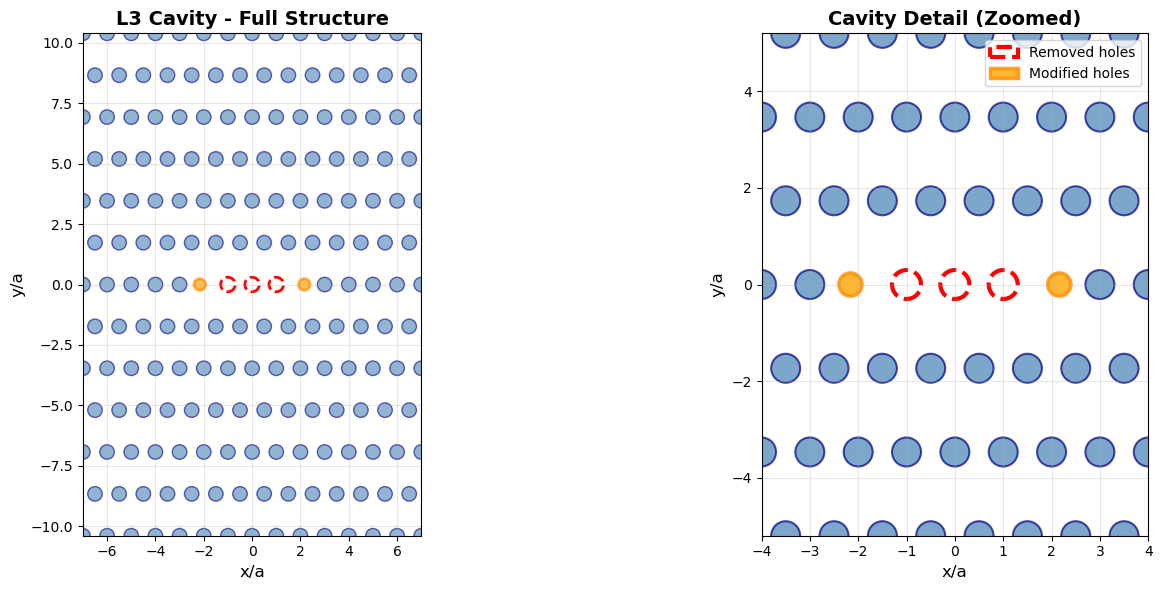

✓ Structure visualization saved as 'l3_structure.png'


In [51]:
def plot_cavity_structure():
    """Plot the L3 cavity structure"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Full structure
    nx_range = 8
    ny_range = 7
    cavity_positions = {(0, 0), (1, 0), (-1, 0)}
    modified_positions = {(2, 0), (-2, 0)}
    
    for i in range(-nx_range, nx_range + 1):
        for j in range(-ny_range, ny_range + 1):
            x_pos = i * a
            y_pos = j * a * np.sqrt(3)
            if j % 2 == 1:
                x_pos += 0.5 * a
            
            if (i, j) in cavity_positions:
                # Cavity holes (removed)
                circle = Circle((x_pos, y_pos), r, color='none', 
                              ec='red', linewidth=2, linestyle='--')
                ax1.add_patch(circle)
            elif (i, j) in modified_positions:
                # Modified holes
                x_mod = x_pos + np.sign(i) * shift
                circle = Circle((x_mod, y_pos), r_modified, 
                              color='orange', alpha=0.7, ec='darkorange', linewidth=2)
                ax1.add_patch(circle)
            else:
                # Regular holes
                circle = Circle((x_pos, y_pos), r, 
                              color='steelblue', alpha=0.6, ec='navy', linewidth=1)
                ax1.add_patch(circle)
    
    ax1.set_xlim(-7*a, 7*a)
    ax1.set_ylim(-6*a*np.sqrt(3), 6*a*np.sqrt(3))
    ax1.set_aspect('equal')
    ax1.set_xlabel('x/a', fontsize=12)
    ax1.set_ylabel('y/a', fontsize=12)
    ax1.set_title('L3 Cavity - Full Structure', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Zoomed cavity region
    for i in range(-4, 5):
        for j in range(-3, 4):
            x_pos = i * a
            y_pos = j * a * np.sqrt(3)
            if j % 2 == 1:
                x_pos += 0.5 * a
            
            if (i, j) in cavity_positions:
                circle = Circle((x_pos, y_pos), r, color='none', 
                              ec='red', linewidth=3, linestyle='--', 
                              label='Removed holes' if i==0 else '')
                ax2.add_patch(circle)
            elif (i, j) in modified_positions:
                x_mod = x_pos + np.sign(i) * shift
                circle = Circle((x_mod, y_pos), r_modified, 
                              color='orange', alpha=0.8, ec='darkorange', linewidth=2.5,
                              label='Modified holes' if i==2 else '')
                ax2.add_patch(circle)
            else:
                circle = Circle((x_pos, y_pos), r, 
                              color='steelblue', alpha=0.7, ec='navy', linewidth=1.5)
                ax2.add_patch(circle)
    
    ax2.set_xlim(-4*a, 4*a)
    ax2.set_ylim(-3*a*np.sqrt(3), 3*a*np.sqrt(3))
    ax2.set_aspect('equal')
    ax2.set_xlabel('x/a', fontsize=12)
    ax2.set_ylabel('y/a', fontsize=12)
    ax2.set_title('Cavity Detail (Zoomed)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('l3_structure.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Structure visualization saved as 'l3_structure.png'")

plot_cavity_structure()

## 6. Configure Source and Symmetries

In [52]:
# Gaussian pulse source in cavity
sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ez,
        center=mp.Vector3(0.5*a, 0, 0),  # Slightly off-center
        size=mp.Vector3(0, 0, 0)
    )
]

# Symmetries to reduce computation
symmetries = [
    mp.Mirror(mp.Y, phase=+1),  # Even in y
    mp.Mirror(mp.X, phase=-1),  # Odd in x (for dipole mode)
]

if dims == 3:
    symmetries.append(mp.Mirror(mp.Z, phase=+1))  # Even in z

print("Source configuration:")
print(f"  Type: Gaussian pulse")
print(f"  Center frequency: {fcen:.3f} (a/λ)")
print(f"  Frequency width: {df:.3f}")
print(f"  Position: (0.5a, 0, 0)")
print(f"\nSymmetries: Y-mirror (even), X-mirror (odd)")
if dims == 3:
    print(f"           Z-mirror (even)")

Source configuration:
  Type: Gaussian pulse
  Center frequency: 0.250 (a/λ)
  Frequency width: 0.200
  Position: (0.5a, 0, 0)

Symmetries: Y-mirror (even), X-mirror (odd)
           Z-mirror (even)


## 7. Create Simulation Object

In [53]:
# Create MEEP simulation
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    sources=sources,
    resolution=RESOLUTION,
    boundary_layers=pml_layers,
    symmetries=symmetries,
    default_material=default_material,
    dimensions=dims
)

print("✓ MEEP Simulation object created")
print(f"  Grid dimensions: {int(sx*RESOLUTION)} × {int(sy*RESOLUTION)}" + 
      (f" × {int(sz*RESOLUTION)}" if dims == 3 else ""))
print(f"  Approximate grid points: {int(sx*sy*RESOLUTION**2):,}" +
      (f" × {int(sz*RESOLUTION)}" if dims == 3 else ""))

✓ MEEP Simulation object created
  Grid dimensions: 300 × 240 × 120
  Approximate grid points: 72,000 × 120


## 8. Run Harminv - Find Resonant Modes

Harminv analyzes the time-domain signal to extract resonant frequencies, Q-factors, and decay rates.

**This will take several minutes** depending on resolution and runtime settings.

In [54]:
print("="*70)
print("RUNNING HARMINV ANALYSIS")
print("="*70)
print("This may take 5-30 minutes depending on settings...")
print("Please be patient!\n")

# Harminv monitor point
harminv_point = mp.Vector3(0.5*a, 0, 0)

# Create Harminv object
h = mp.Harminv(mp.Ez, harminv_point, fcen, df)

# Run simulation
sim.run(mp.after_sources(h), until_after_sources=RUNTIME)

print("\n" + "="*70)
print("HARMINV ANALYSIS COMPLETE")
print("="*70)

RUNNING HARMINV ANALYSIS
This may take 5-30 minutes depending on settings...
Please be patient!

-----------
Initializing structure...
Halving computational cell along direction x
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.0046401 s
Working in 3D dimensions.
Computational cell is 15 x 12 x 6 with resolution 20
     block, center = (0,0,0)
          size (15,12,0.6)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.9716,11.9716,11.9716)
     cylinder, center = (-7.5,-12.1244,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-8,-10.3923,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-7.5,-8.66025,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (

FloatProgress(value=0.0, description='0% done ', max=250.0)

Meep progress: 2.5250000000000004/250.0 = 1.0% done in 4.0s, 394.3s to go
on time step 101 (time=2.525), 0.0397583 s/step
Meep progress: 6.550000000000001/250.0 = 2.6% done in 8.0s, 298.5s to go
on time step 262 (time=6.55), 0.0248831 s/step
Meep progress: 11.325000000000001/250.0 = 4.5% done in 12.0s, 253.8s to go
on time step 453 (time=11.325), 0.0210098 s/step
Meep progress: 15.375/250.0 = 6.2% done in 16.1s, 245.2s to go
on time step 615 (time=15.375), 0.0248256 s/step
Meep progress: 19.625/250.0 = 7.8% done in 20.1s, 235.7s to go
on time step 785 (time=19.625), 0.0235995 s/step
Meep progress: 23.900000000000002/250.0 = 9.6% done in 24.1s, 227.9s to go
on time step 956 (time=23.9), 0.0234703 s/step
Meep progress: 28.1/250.0 = 11.2% done in 28.1s, 221.9s to go
on time step 1124 (time=28.1), 0.0238554 s/step
Meep progress: 32.300000000000004/250.0 = 12.9% done in 32.1s, 216.5s to go
on time step 1292 (time=32.3), 0.0239161 s/step
Meep progress: 36.375/250.0 = 14.6% done in 36.1s, 212

## 9. Analyze Resonances

In [55]:
# Extract and display resonances
print("\nRESULTS - Resonant Modes:\n")
print("="*70)

resonances = []

for i, mode in enumerate(h.modes):
    freq = mode.freq
    Q = mode.Q
    decay = mode.decay
    amplitude = abs(mode.amp)
    
    print(f"\nMode {i+1}:")
    print(f"  Frequency:     f = {freq:.6f} (a/λ)")
    print(f"  Wavelength:    λ/a = {1/freq:.4f}")
    print(f"  Q-factor:      Q = {Q:.1f}")
    print(f"  Decay rate:    γ = {decay:.6e}")
    print(f"  Amplitude:     |A| = {amplitude:.4f}")
    
    # Store high-Q modes
    if Q > 50 and amplitude > 0.01:
        resonances.append((freq, Q, amplitude, i))

print("\n" + "="*70)

# Select fundamental mode
if not resonances:
    print("\n⚠ Warning: No high-Q resonances found!")
    print("Using center frequency for field calculation.")
    resonant_freq = fcen
    Q_factor = 0
else:
    # Sort by Q-factor
    resonances.sort(key=lambda x: x[1], reverse=True)
    resonant_freq, Q_factor, amp, mode_idx = resonances[0]
    
    print("\n" + "="*70)
    print("SELECTED FUNDAMENTAL MODE")
    print("="*70)
    print(f"Frequency:     f = {resonant_freq:.6f} (a/λ)")
    print(f"Wavelength:    λ/a = {1/resonant_freq:.4f}")
    print(f"Q-factor:      Q = {Q_factor:.1f}")
    print(f"Amplitude:     |A| = {amp:.4f}")
    
    # For real dimensions (a = 240 nm)
    lambda_nm = 240 * (1/resonant_freq)
    print(f"\nFor a = 240 nm:")
    print(f"  Wavelength: λ ≈ {lambda_nm:.0f} nm")
    print("="*70)

# Store results
results = {
    'frequency': resonant_freq,
    'Q_factor': Q_factor,
    'wavelength': 1/resonant_freq,
    'num_modes': len(resonances)
}


RESULTS - Resonant Modes:


Mode 1:
  Frequency:     f = 0.227757 (a/λ)
  Wavelength:    λ/a = 4.3906
  Q-factor:      Q = 61.8
  Decay rate:    γ = -1.844139e-03
  Amplitude:     |A| = 0.0114

Mode 2:
  Frequency:     f = 0.250640 (a/λ)
  Wavelength:    λ/a = 3.9898
  Q-factor:      Q = 65.4
  Decay rate:    γ = -1.916463e-03
  Amplitude:     |A| = 0.3730

Mode 3:
  Frequency:     f = 0.262498 (a/λ)
  Wavelength:    λ/a = 3.8095
  Q-factor:      Q = 82.1
  Decay rate:    γ = -1.598881e-03
  Amplitude:     |A| = 0.5477

Mode 4:
  Frequency:     f = 0.328378 (a/λ)
  Wavelength:    λ/a = 3.0453
  Q-factor:      Q = 110.9
  Decay rate:    γ = -1.480461e-03
  Amplitude:     |A| = 0.0119

Mode 5:
  Frequency:     f = 0.339648 (a/λ)
  Wavelength:    λ/a = 2.9442
  Q-factor:      Q = 76.3
  Decay rate:    γ = -2.225680e-03
  Amplitude:     |A| = 0.0155


SELECTED FUNDAMENTAL MODE
Frequency:     f = 0.328378 (a/λ)
Wavelength:    λ/a = 3.0453
Q-factor:      Q = 110.9
Amplitude:     |A| = 0.011

## 10. Calculate Field Distribution at Resonance

Now we'll restart the simulation with a continuous wave source at the resonant frequency to get the steady-state field distribution.

In [56]:
print("Calculating field distribution at resonance...")
print("This may take several minutes...\n")

# Reset simulation
sim.reset_meep()

# Continuous wave source at resonance
sim.sources = [
    mp.Source(
        mp.ContinuousSource(frequency=resonant_freq, width=5),
        component=mp.Ez,
        center=mp.Vector3(0.5*a, 0, 0),
        size=mp.Vector3(0, 0, 0)
    )
]

# Run to steady state
sim.run(until=400)

print("✓ Field calculation complete!")

Calculating field distribution at resonance...
This may take several minutes...

-----------
Initializing structure...
Halving computational cell along direction x
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.00392008 s
Working in 3D dimensions.
Computational cell is 15 x 12 x 6 with resolution 20
     block, center = (0,0,0)
          size (15,12,0.6)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.9716,11.9716,11.9716)
     cylinder, center = (-7.5,-12.1244,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-8,-10.3923,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-7.5,-8.66025,0)
          radius 0.3, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cyl

FloatProgress(value=0.0, description='0% done ', max=400.0)

Meep progress: 3.1/400.0 = 0.8% done in 4.0s, 512.9s to go
on time step 124 (time=3.1), 0.0322843 s/step
Meep progress: 7.550000000000001/400.0 = 1.9% done in 8.0s, 417.2s to go
on time step 302 (time=7.55), 0.0225766 s/step
Meep progress: 12.075000000000001/400.0 = 3.0% done in 12.0s, 386.4s to go
on time step 483 (time=12.075), 0.022108 s/step
Meep progress: 16.5/400.0 = 4.1% done in 16.0s, 372.9s to go
on time step 660 (time=16.5), 0.0226961 s/step
Meep progress: 20.925/400.0 = 5.2% done in 20.1s, 363.6s to go
on time step 837 (time=20.925), 0.0227364 s/step
Meep progress: 25.425/400.0 = 6.4% done in 24.1s, 354.9s to go
on time step 1017 (time=25.425), 0.0223285 s/step
Meep progress: 31.475/400.0 = 7.9% done in 28.1s, 329.0s to go
on time step 1259 (time=31.475), 0.0165666 s/step
Meep progress: 36.125/400.0 = 9.0% done in 32.1s, 323.6s to go
on time step 1445 (time=36.125), 0.0216097 s/step
Meep progress: 40.7/400.0 = 10.2% done in 36.1s, 319.0s to go
on time step 1628 (time=40.7), 

## 11. Extract Field Data

In [57]:
print("Extracting field data...")

# Define slice volume (z=0 plane)
if dims == 3:
    slice_volume = mp.Volume(center=mp.Vector3(), size=mp.Vector3(sx, sy, 0))
else:
    slice_volume = mp.Volume(center=mp.Vector3(), size=mp.Vector3(sx, sy, 0))

# Extract fields
ez_data = sim.get_array(vol=slice_volume, component=mp.Ez)
eps_data = sim.get_array(vol=slice_volume, component=mp.Dielectric)

# Get array dimensions
nx, ny = ez_data.shape
x_coords = np.linspace(-sx/2, sx/2, nx)
y_coords = np.linspace(-sy/2, sy/2, ny)

# Calculate intensity
intensity = np.abs(ez_data)**2

print(f"✓ Extracted field arrays: {nx} × {ny} points")
print(f"  Ez field (complex): {ez_data.shape}")
print(f"  Permittivity: {eps_data.shape}")
print(f"  Intensity: {intensity.shape}")

Extracting field data...
✓ Extracted field arrays: 300 × 240 points
  Ez field (complex): (300, 240)
  Permittivity: (300, 240)
  Intensity: (300, 240)


## 12. Visualization - Field Distribution

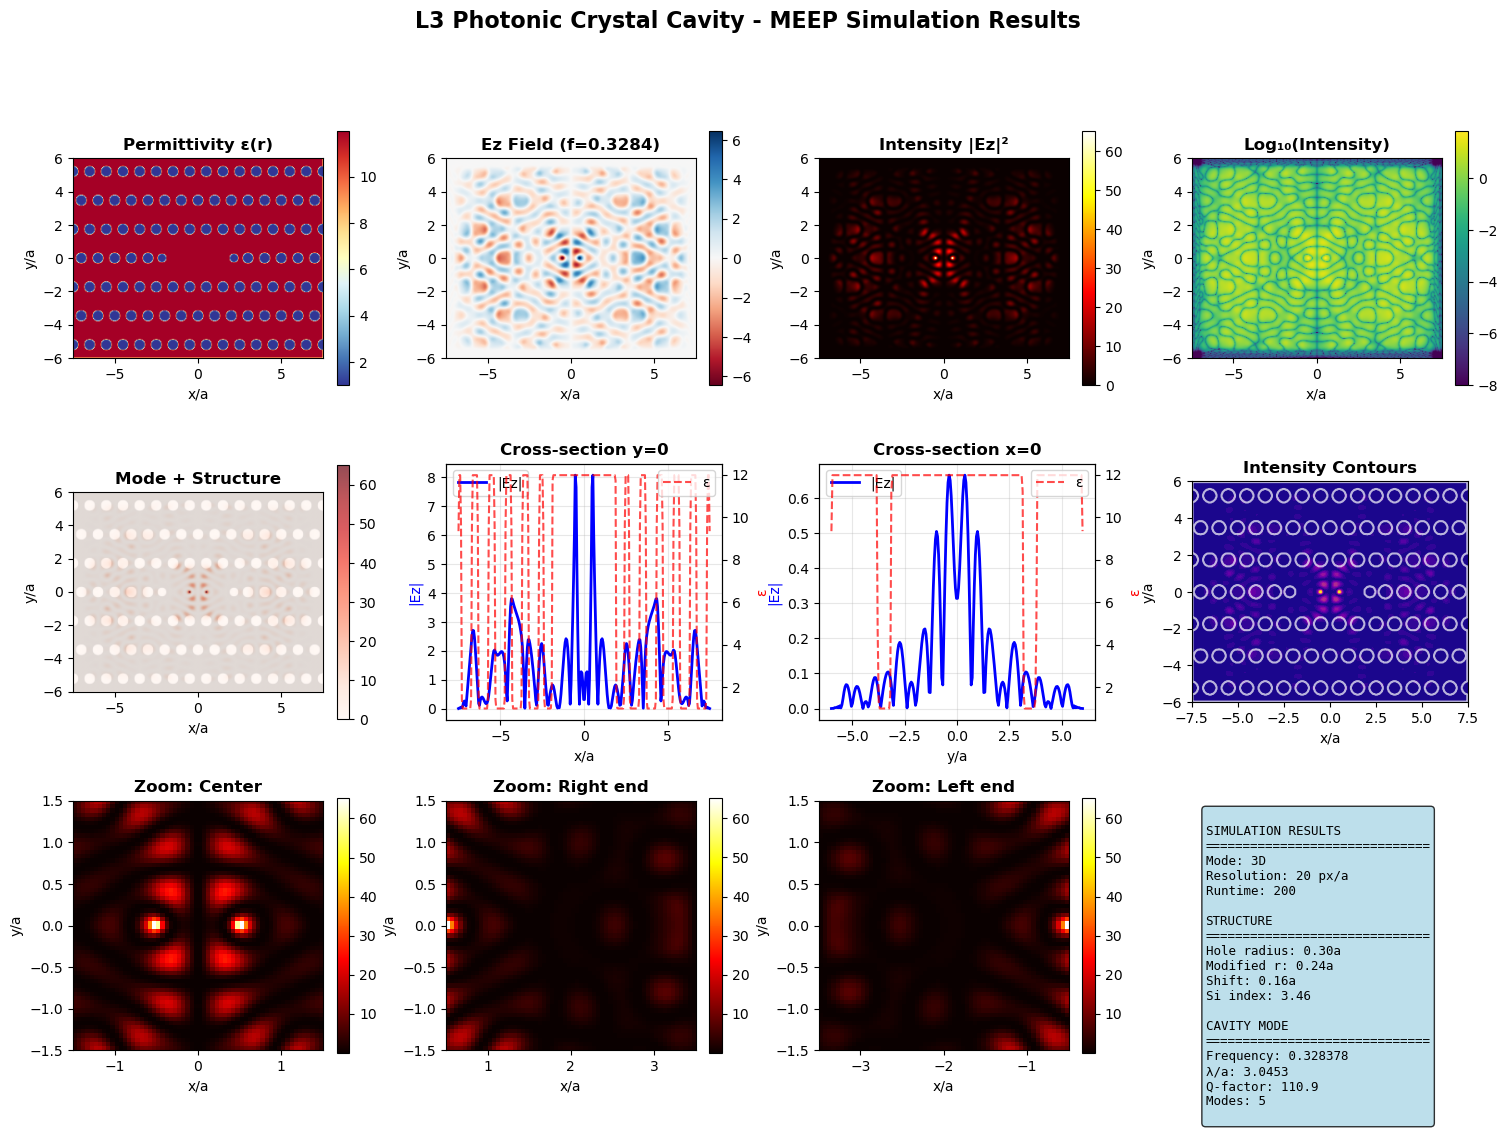

✓ Complete visualization saved as 'l3_meep_results.png'


In [58]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.35)

extent = [-sx/2, sx/2, -sy/2, sy/2]

# 1. Permittivity
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(np.transpose(eps_data), extent=extent, cmap='RdYlBu_r', origin='lower')
ax1.set_title('Permittivity ε(r)', fontweight='bold')
ax1.set_xlabel('x/a')
ax1.set_ylabel('y/a')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# 2. Ez field
ax2 = fig.add_subplot(gs[0, 1])
ez_real = np.real(ez_data)
vmax = np.abs(ez_real).max() * 0.8
im2 = ax2.imshow(np.transpose(ez_real), extent=extent, cmap='RdBu', 
                 origin='lower', vmin=-vmax, vmax=vmax)
ax2.set_title(f'Ez Field (f={resonant_freq:.4f})', fontweight='bold')
ax2.set_xlabel('x/a')
ax2.set_ylabel('y/a')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# 3. Intensity
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(np.transpose(intensity), extent=extent, cmap='hot', origin='lower')
ax3.set_title('Intensity |Ez|²', fontweight='bold')
ax3.set_xlabel('x/a')
ax3.set_ylabel('y/a')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# 4. Log intensity
ax4 = fig.add_subplot(gs[0, 3])
log_int = np.log10(intensity + 1e-8)
im4 = ax4.imshow(np.transpose(log_int), extent=extent, cmap='viridis', origin='lower')
ax4.set_title('Log₁₀(Intensity)', fontweight='bold')
ax4.set_xlabel('x/a')
ax4.set_ylabel('y/a')
plt.colorbar(im4, ax=ax4, fraction=0.046)

# 5. Overlay
ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(np.transpose(eps_data), extent=extent, cmap='gray_r', origin='lower', alpha=0.4)
im5 = ax5.imshow(np.transpose(intensity), extent=extent, cmap='Reds', origin='lower', alpha=0.7)
ax5.set_title('Mode + Structure', fontweight='bold')
ax5.set_xlabel('x/a')
ax5.set_ylabel('y/a')
plt.colorbar(im5, ax=ax5, fraction=0.046)

# 6. X cross-section
ax6 = fig.add_subplot(gs[1, 1])
mid_y = ny // 2
ax6_twin = ax6.twinx()
ax6.plot(x_coords, np.abs(ez_data[:, mid_y]), 'b-', linewidth=2, label='|Ez|')
ax6_twin.plot(x_coords, eps_data[:, mid_y], 'r--', linewidth=1.5, alpha=0.7, label='ε')
ax6.set_xlabel('x/a')
ax6.set_ylabel('|Ez|', color='b')
ax6_twin.set_ylabel('ε', color='r')
ax6.set_title('Cross-section y=0', fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.legend(loc='upper left')
ax6_twin.legend(loc='upper right')

# 7. Y cross-section
ax7 = fig.add_subplot(gs[1, 2])
mid_x = nx // 2
ax7_twin = ax7.twinx()
ax7.plot(y_coords, np.abs(ez_data[mid_x, :]), 'b-', linewidth=2, label='|Ez|')
ax7_twin.plot(y_coords, eps_data[mid_x, :], 'r--', linewidth=1.5, alpha=0.7, label='ε')
ax7.set_xlabel('y/a')
ax7.set_ylabel('|Ez|', color='b')
ax7_twin.set_ylabel('ε', color='r')
ax7.set_title('Cross-section x=0', fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.legend(loc='upper left')
ax7_twin.legend(loc='upper right')

# 8. Contours
ax8 = fig.add_subplot(gs[1, 3])
levels = np.linspace(0, intensity.max(), 25)
cs = ax8.contourf(x_coords, y_coords, np.transpose(intensity), levels=levels, cmap='plasma')
ax8.contour(x_coords, y_coords, np.transpose(eps_data), 
            levels=[n_si**2-0.5], colors='white', linewidths=1.5, alpha=0.7)
ax8.set_title('Intensity Contours', fontweight='bold')
ax8.set_xlabel('x/a')
ax8.set_ylabel('y/a')
ax8.set_aspect('equal')

# 9-11. Zoomed views
zoom_locations = [(0, 0, 'Center'), (2*a, 0, 'Right end'), (-2*a, 0, 'Left end')]
for idx, (zoom_x, zoom_y, title) in enumerate(zoom_locations):
    ax = fig.add_subplot(gs[2, idx])
    zoom_size = 3*a
    
    x_mask = (x_coords >= zoom_x-zoom_size/2) & (x_coords <= zoom_x+zoom_size/2)
    y_mask = (y_coords >= zoom_y-zoom_size/2) & (y_coords <= zoom_y+zoom_size/2)
    
    zoom_data = intensity[np.ix_(x_mask, y_mask)]
    zoom_extent = [zoom_x-zoom_size/2, zoom_x+zoom_size/2, 
                   zoom_y-zoom_size/2, zoom_y+zoom_size/2]
    
    im = ax.imshow(np.transpose(zoom_data), extent=zoom_extent, 
                   cmap='hot', origin='lower')
    ax.set_title(f'Zoom: {title}', fontweight='bold')
    ax.set_xlabel('x/a')
    ax.set_ylabel('y/a')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

# 12. Info panel
ax12 = fig.add_subplot(gs[2, 3])
ax12.axis('off')
info_text = f"""
SIMULATION RESULTS
{'='*30}
Mode: {'2D' if dims==2 else '3D'}
Resolution: {RESOLUTION} px/a
Runtime: {RUNTIME}

STRUCTURE
{'='*30}
Hole radius: {r:.2f}a
Modified r: {r_modified:.2f}a
Shift: {shift:.2f}a
Si index: {n_si}

CAVITY MODE
{'='*30}
Frequency: {resonant_freq:.6f}
λ/a: {1/resonant_freq:.4f}
Q-factor: {Q_factor:.1f}
Modes: {len(resonances)}
"""
ax12.text(0.05, 0.95, info_text, transform=ax12.transAxes,
          fontsize=9, verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('L3 Photonic Crystal Cavity - MEEP Simulation Results', 
             fontsize=16, fontweight='bold')
plt.savefig('l3_meep_results.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Complete visualization saved as 'l3_meep_results.png'")

## 13. Additional Analysis - Mode Profile

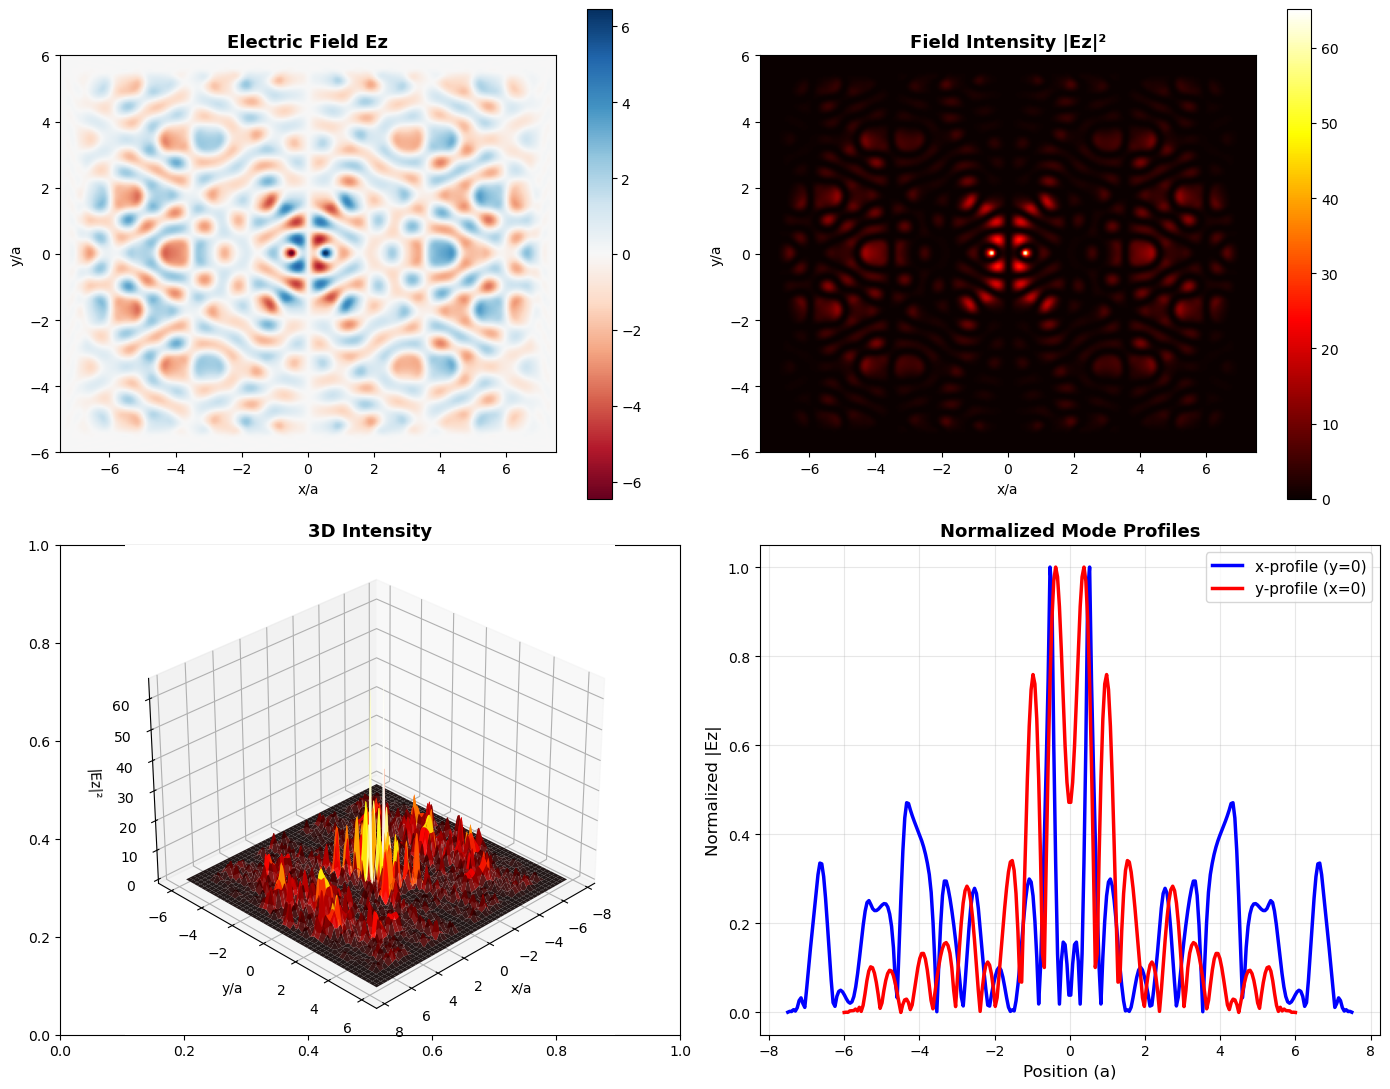

✓ Mode analysis saved as 'l3_mode_analysis.png'


In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# High-res field
vmax = np.abs(ez_real).max() * 0.8
im1 = axes[0, 0].imshow(np.transpose(ez_real), extent=extent, cmap='RdBu',
                        origin='lower', vmin=-vmax, vmax=vmax)
axes[0, 0].set_title('Electric Field Ez', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('x/a')
axes[0, 0].set_ylabel('y/a')
axes[0, 0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0, 0])

# High-res intensity
im2 = axes[0, 1].imshow(np.transpose(intensity), extent=extent, cmap='hot', origin='lower')
axes[0, 1].set_title('Field Intensity |Ez|²', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('x/a')
axes[0, 1].set_ylabel('y/a')
axes[0, 1].set_aspect('equal')
plt.colorbar(im2, ax=axes[0, 1])

# 3D surface
ax_3d = fig.add_subplot(2, 2, 3, projection='3d')
X_grid, Y_grid = np.meshgrid(x_coords, y_coords)
surf = ax_3d.plot_surface(X_grid, Y_grid, np.transpose(intensity), 
                          cmap='hot', alpha=0.9, linewidth=0, antialiased=True)
ax_3d.set_xlabel('x/a')
ax_3d.set_ylabel('y/a')
ax_3d.set_zlabel('|Ez|²')
ax_3d.set_title('3D Intensity', fontsize=13, fontweight='bold')
ax_3d.view_init(elev=30, azim=45)

# Normalized profiles
ez_x_norm = np.abs(ez_data[:, mid_y]) / np.abs(ez_data[:, mid_y]).max()
ez_y_norm = np.abs(ez_data[mid_x, :]) / np.abs(ez_data[mid_x, :]).max()

axes[1, 1].plot(x_coords, ez_x_norm, 'b-', linewidth=2.5, label='x-profile (y=0)')
axes[1, 1].plot(y_coords, ez_y_norm, 'r-', linewidth=2.5, label='y-profile (x=0)')
axes[1, 1].set_xlabel('Position (a)', fontsize=12)
axes[1, 1].set_ylabel('Normalized |Ez|', fontsize=12)
axes[1, 1].set_title('Normalized Mode Profiles', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('l3_mode_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Mode analysis saved as 'l3_mode_analysis.png'")

## 14. Summary Statistics

In [60]:
# Calculate additional metrics
max_intensity = intensity.max()
total_energy = intensity.sum()

# Find peak location
peak_idx = np.unravel_index(intensity.argmax(), intensity.shape)
peak_x = x_coords[peak_idx[0]]
peak_y = y_coords[peak_idx[1]]

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nSimulation Configuration:")
print(f"  Mode: {'2D' if dims==2 else '3D'}")
print(f"  Resolution: {RESOLUTION} pixels/a")
print(f"  Runtime: {RUNTIME} time units")
print(f"\nCavity Parameters:")
print(f"  Lattice constant: a (normalized to 1.0)")
print(f"  Hole radius: {r:.2f}a = {r*240:.1f} nm (for a=240nm)")
print(f"  Modified radius: {r_modified:.2f}a = {r_modified*240:.1f} nm")
print(f"  End hole shift: {shift:.2f}a = {shift*240:.1f} nm")
print(f"  Silicon index: {n_si}")
print(f"\nResonance Results:")
print(f"  Frequency: f = {resonant_freq:.6f} (a/λ)")
print(f"  Wavelength: λ/a = {1/resonant_freq:.4f}")
print(f"  Q-factor: Q = {Q_factor:.1f}")
print(f"  Modes found: {len(resonances)}")
print(f"\nFor a = 240 nm:")
print(f"  Wavelength: λ ≈ {240*(1/resonant_freq):.0f} nm")
print(f"\nField Distribution:")
print(f"  Peak intensity: {max_intensity:.6e}")
print(f"  Peak location: ({peak_x:.3f}, {peak_y:.3f}) [units of a]")
print(f"  Total energy: {total_energy:.6e}")
print(f"\nOutput Files:")
print(f"  • l3_structure.png - Cavity geometry")
print(f"  • l3_meep_results.png - Complete field analysis")
print(f"  • l3_mode_analysis.png - Mode profiles")
print("="*70)

# Save results dictionary
results.update({
    'max_intensity': max_intensity,
    'peak_location': (peak_x, peak_y),
    'resolution': RESOLUTION,
    'runtime': RUNTIME,
    'dimensions': dims
})

print("\n✓ Simulation complete!")


FINAL SUMMARY

Simulation Configuration:
  Mode: 3D
  Resolution: 20 pixels/a
  Runtime: 200 time units

Cavity Parameters:
  Lattice constant: a (normalized to 1.0)
  Hole radius: 0.30a = 72.0 nm (for a=240nm)
  Modified radius: 0.24a = 57.6 nm
  End hole shift: 0.16a = 38.4 nm
  Silicon index: 3.46

Resonance Results:
  Frequency: f = 0.328378 (a/λ)
  Wavelength: λ/a = 3.0453
  Q-factor: Q = 110.9
  Modes found: 5

For a = 240 nm:
  Wavelength: λ ≈ 731 nm

Field Distribution:
  Peak intensity: 6.514054e+01
  Peak location: (-0.527, -0.025) [units of a]
  Total energy: 9.361187e+04

Output Files:
  • l3_structure.png - Cavity geometry
  • l3_meep_results.png - Complete field analysis
  • l3_mode_analysis.png - Mode profiles

✓ Simulation complete!


## 15. Export Results

In [61]:
# Save field data for further analysis
import pickle

data_export = {
    'ez_field': ez_data,
    'permittivity': eps_data,
    'intensity': intensity,
    'x_coords': x_coords,
    'y_coords': y_coords,
    'results': results,
    'parameters': {
        'a': a,
        'r': r,
        'r_modified': r_modified,
        'shift': shift,
        'n_si': n_si,
        'resolution': RESOLUTION
    }
}

with open('l3_simulation_data.pkl', 'wb') as f:
    pickle.dump(data_export, f)

print("✓ Simulation data exported to 'l3_simulation_data.pkl'")
print("\nYou can load this data later with:")
print("  import pickle")
print("  with open('l3_simulation_data.pkl', 'rb') as f:")
print("      data = pickle.load(f)")

✓ Simulation data exported to 'l3_simulation_data.pkl'

You can load this data later with:
  import pickle
  with open('l3_simulation_data.pkl', 'rb') as f:
      data = pickle.load(f)


## Next Steps

### To improve Q-factor:
1. Increase resolution (`RESOLUTION = 40`)
2. Increase runtime (`RUNTIME = 500`)
3. Fine-tune hole positions and radii
4. Add more modified holes

### To analyze further:
1. Calculate mode volume
2. Compute Purcell factor
3. Sweep parameters (hole radius, shift distance)
4. Add waveguide coupling
5. Study transmission spectra

### References:
- Akahane et al., Nature 425, 944 (2003)
- Song et al., Nature Materials 4, 207 (2005)
- Lodahl et al., Rev. Mod. Phys. 87, 347 (2015)